# Baseline and Context Analysis

This is mainly for background checks and simple baseline numbers.

## Things to Check Here

1. How many matches, points, and players are in the dataset
2. How often does the same player win two points in a row
3. How big is the serving advantage
4. Do break points, deuce points, or advantage points look different
5. Which numbers/figures might be useful for the final report

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("data/2024_Wimbledon_featured_matches.csv")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

In [21]:
raw = pd.read_csv(DATA_PATH)

# Preserve the CSV order within each match. The rows are already point-by-point.
df = raw.reset_index(drop=True).copy()
df["point_index_in_match"] = df.groupby("match_id").cumcount() + 1

df.head()

,match_id,player1,player2,elapsed_time,set_no,game_no,point_no,p1_sets,p2_sets,p1_games,...,p1_break_pt_missed,p2_break_pt_missed,p1_distance_run,p2_distance_run,rally_count,speed_mph,serve_width,serve_depth,return_depth,point_index_in_match
0,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:00:00,1,1,1,0,0,0,...,0,0,6.000,7.840,2,95.0,BC,NCTL,ND,1
1,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:00:38,1,1,2,0,0,0,...,0,0,5.253,7.094,1,118.0,B,CTL,ND,2
2,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:01:01,1,1,3,0,0,0,...,0,0,13.800,19.808,4,120.0,B,NCTL,D,3
3,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:01:31,1,1,4,0,0,0,...,0,0,51.108,75.631,13,130.0,BW,CTL,D,4
4,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,00:02:21,1,1,5,0,0,0,...,0,0,0.649,0.813,1,112.0,W,NCTL,NaN,5


Dataset Overview

In [22]:
players = pd.Series(df[["player1", "player2"]].values.ravel()).drop_duplicates()

dataset_summary = pd.DataFrame(
    {
        "quantity": [
            "points",
            "matches",
            "unique players",
            "first match id",
            "last match id",
        ],
        "value": [
            len(df),
            df["match_id"].nunique(),
            players.nunique(),
            df["match_id"].iloc[0],
            df["match_id"].iloc[-1],
        ],
    }
)

dataset_summary

,quantity,value
0,points,7284
1,matches,31
2,unique players,32
3,first match id,2023-wimbledon-1301
4,last match id,2023-wimbledon-1701


In [23]:
match_summary = (
    df.groupby(["match_id", "player1", "player2"])
    .agg(points=("point_victor", "size"), p1_point_win_rate=("point_victor", lambda s: (s == 1).mean()))
    .reset_index()
)

match_summary.head(10)

,match_id,player1,player2,points,p1_point_win_rate
0,2023-wimbledon-1301,Carlos Alcaraz,Nicolas Jarry,300,0.526667
1,2023-wimbledon-1302,Alexander Zverev,Matteo Berrettini,201,0.492537
2,2023-wimbledon-1303,Frances Tiafoe,Grigor Dimitrov,134,0.380597
3,2023-wimbledon-1304,Alejandro Davidovich Fokina,Holger Rune,337,0.501484
4,2023-wimbledon-1305,Daniil Medvedev,Marton Fucsovics,246,0.524390
5,2023-wimbledon-1306,Jiri Lehecka,Tommy Paul,332,0.530120
6,2023-wimbledon-1307,Christopher Eubanks,Christopher O'Connell,232,0.530172
7,2023-wimbledon-1308,Laslo Djere,Stefanos Tsitsipas,190,0.473684
8,2023-wimbledon-1309,Jannik Sinner,Quentin Halys,213,0.539906
9,2023-wimbledon-1310,Daniel Elahi Galan,Mikael Ymer,318,0.512579


## Context Features

Some simple context variables. The main ones are who served, who won the last point, whether the server changed, and whether the point was in a pressure situation like break point or deuce.

In [24]:
def score_context(row):
    p1_score = str(row["p1_score"])
    p2_score = str(row["p2_score"])
    if bool(row["break_point"]):
        return "break point"
    if p1_score == "40" and p2_score == "40":
        return "deuce"
    if p1_score == "AD" or p2_score == "AD":
        return "advantage"
    return "ordinary"


df["server_won"] = df["server"] == df["point_victor"]
df["p1_won"] = df["point_victor"] == 1
df["break_point"] = (df["p1_break_pt"] == 1) | (df["p2_break_pt"] == 1)
df["prev_point_victor"] = df.groupby("match_id")["point_victor"].shift(1)
df["prev_server"] = df.groupby("match_id")["server"].shift(1)
df["same_player_consecutive"] = df["point_victor"] == df["prev_point_victor"]
df["same_server_as_previous"] = df["server"] == df["prev_server"]
df["score_context"] = df.apply(score_context, axis=1)

interior = df.dropna(subset=["prev_point_victor", "prev_server"]).copy()
df[["match_id", "point_index_in_match", "server", "point_victor", "prev_point_victor", "server_won", "score_context"]].head(10)

,match_id,point_index_in_match,server,point_victor,prev_point_victor,server_won,score_context
0,2023-wimbledon-1301,1,1,2,NaN,False,ordinary
1,2023-wimbledon-1301,2,1,1,2.0,True,ordinary
2,2023-wimbledon-1301,3,1,2,1.0,False,ordinary
3,2023-wimbledon-1301,4,1,1,2.0,True,ordinary
4,2023-wimbledon-1301,5,1,1,1.0,True,ordinary
5,2023-wimbledon-1301,6,1,2,1.0,False,ordinary
6,2023-wimbledon-1301,7,1,1,2.0,True,deuce
7,2023-wimbledon-1301,8,1,2,1.0,False,advantage
8,2023-wimbledon-1301,9,1,1,2.0,True,deuce
9,2023-wimbledon-1301,10,1,1,1.0,True,advantage


## Null Baseline: Consecutive Point Winners

$$p^2 + (1-p)^2.$$


In [25]:
point_counts = df.groupby("match_id")["point_victor"].value_counts().unstack(fill_value=0)
point_counts["p1_point_win_rate"] = point_counts[1] / (point_counts[1] + point_counts[2])
point_counts["null_same_winner_rate"] = point_counts["p1_point_win_rate"] ** 2 + (1 - point_counts["p1_point_win_rate"]) ** 2

observed_by_match = interior.groupby("match_id")["same_player_consecutive"].mean()
baseline_by_match = point_counts.join(observed_by_match.rename("observed_same_winner_rate"))
baseline_by_match[["p1_point_win_rate", "null_same_winner_rate", "observed_same_winner_rate"]].head()

,p1_point_win_rate,null_same_winner_rate,observed_same_winner_rate
match_id,,,
2023-wimbledon-1301,0.526667,0.501422,0.488294
2023-wimbledon-1302,0.492537,0.500111,0.535000
2023-wimbledon-1303,0.380597,0.528514,0.556391
2023-wimbledon-1304,0.501484,0.500004,0.532738
2023-wimbledon-1305,0.524390,0.501190,0.518367


In [26]:
weighted_null = np.average(
    baseline_by_match["null_same_winner_rate"],
    weights=baseline_by_match[[1, 2]].sum(axis=1) - 1,
)

baseline_rates = pd.DataFrame(
    {
        "metric": [
            "null same-winner rate",
            "observed same-winner rate",
            "server point win rate",
        ],
        "rate": [
            weighted_null,
            interior["same_player_consecutive"].mean(),
            df["server_won"].mean(),
        ],
    }
)

baseline_rates

,metric,rate
0,null same-winner rate,0.503962
1,observed same-winner rate,0.533710
2,server point win rate,0.673119


## Serve Context

If the same player keeps winning points during a service game, that might just be because serving is a big advantage, not necessarily because of momentum.

In [27]:
serve_context = pd.DataFrame(
    {
        "context": [
            "all interior points",
            "same server as previous point",
            "server changed from previous point",
        ],
        "same_winner_rate": [
            interior["same_player_consecutive"].mean(),
            interior.loc[interior["same_server_as_previous"], "same_player_consecutive"].mean(),
            interior.loc[~interior["same_server_as_previous"], "same_player_consecutive"].mean(),
        ],
        "n_points": [
            len(interior),
            int(interior["same_server_as_previous"].sum()),
            int((~interior["same_server_as_previous"]).sum()),
        ],
    }
)

serve_context

,context,same_winner_rate,n_points
0,all interior points,0.533710,7253
1,same server as previous point,0.561309,5929
2,server changed from previous point,0.410121,1324


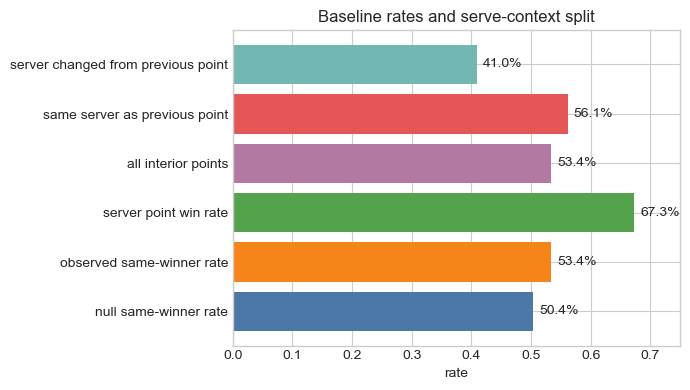

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_data = pd.concat(
    [
        baseline_rates.assign(group="baseline")[["metric", "rate"]],
        serve_context.rename(columns={"context": "metric", "same_winner_rate": "rate"})[["metric", "rate"]],
    ],
    ignore_index=True,
).drop_duplicates("metric")

colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756", "#72B7B2"]
ax.barh(plot_data["metric"], plot_data["rate"], color=colors[: len(plot_data)])
ax.set_xlim(0, 0.75)
ax.set_xlabel("rate")
ax.set_title("Baseline rates and serve-context split")
for i, rate in enumerate(plot_data["rate"]):
    ax.text(rate + 0.01, i, f"{rate:.1%}", va="center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_serve_context_rates.png", dpi=200)
plt.show()

## Streak Length

Checks whether longer streaks keep going more often.

In [29]:
streak_rows = []
for k in range(1, 6):
    temp = df.copy()
    lag_cols = []
    for lag in range(1, k + 1):
        col = f"lag_{lag}_winner"
        temp[col] = temp.groupby("match_id")["point_victor"].shift(lag)
        lag_cols.append(col)

    complete = temp.dropna(subset=lag_cols).copy()
    previous_k_same_player = complete[lag_cols].eq(complete[lag_cols[0]], axis=0).all(axis=1)
    streak_points = complete.loc[previous_k_same_player].copy()
    continued = streak_points["point_victor"] == streak_points[lag_cols[0]]

    streak_rows.append(
        {
            "previous_streak_length": k,
            "continuation_rate": continued.mean(),
            "n_points": len(streak_points),
        }
    )

streak_summary = pd.DataFrame(streak_rows)
streak_summary

,previous_streak_length,continuation_rate,n_points
0,1,0.533710,7253
1,2,0.527532,3850
2,3,0.498512,2016
3,4,0.428858,998
4,5,0.427230,426


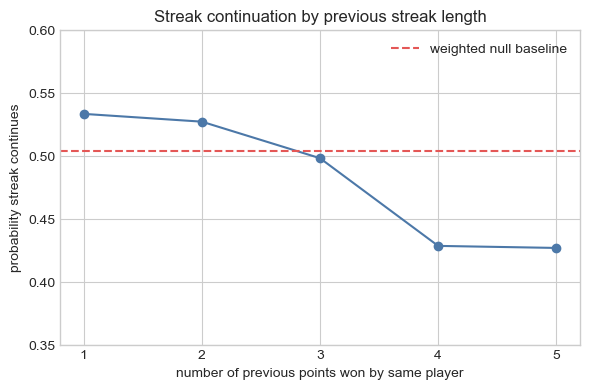

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(streak_summary["previous_streak_length"], streak_summary["continuation_rate"], marker="o", color="#4C78A8")
ax.axhline(weighted_null, color="#E45756", linestyle="--", label="weighted null baseline")
ax.set_ylim(0.35, 0.60)
ax.set_xticks(streak_summary["previous_streak_length"])
ax.set_xlabel("number of previous points won by same player")
ax.set_ylabel("probability streak continues")
ax.set_title("Streak continuation by previous streak length")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "streak_continuation_rates.png", dpi=200)
plt.show()

## Score Pressure

In [31]:
score_context_summary = (
    df.groupby("score_context")
    .agg(
        n_points=("point_victor", "size"),
        server_win_rate=("server_won", "mean"),
        p1_win_rate=("p1_won", "mean"),
        avg_rally_count=("rally_count", "mean"),
        avg_serve_speed=("speed_mph", "mean"),
    )
    .sort_values("n_points", ascending=False)
)

score_context_summary

,n_points,server_win_rate,p1_win_rate,avg_rally_count,avg_serve_speed
score_context,,,,,
ordinary,6060,0.675908,0.512541,3.066502,112.338170
break point,504,0.648810,0.500000,3.468254,112.521640
deuce,431,0.670534,0.505800,3.433875,113.198454
advantage,289,0.660900,0.491349,3.391003,112.540230


In [32]:
score_same_winner = (
    interior.groupby("score_context")
    .agg(
        n_points=("point_victor", "size"),
        same_winner_rate=("same_player_consecutive", "mean"),
        same_server_share=("same_server_as_previous", "mean"),
    )
    .sort_values("n_points", ascending=False)
)

score_same_winner

,n_points,same_winner_rate,same_server_share
score_context,,,
ordinary,6029,0.539061,0.780395
break point,504,0.428571,1.000000
deuce,431,0.496520,1.000000
advantage,289,0.660900,1.000000


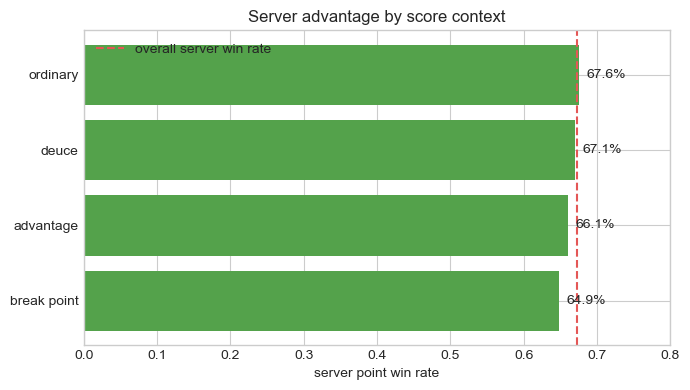

In [33]:
fig, ax = plt.subplots(figsize=(7, 4))
ordered = score_context_summary.sort_values("server_win_rate", ascending=True)
ax.barh(ordered.index, ordered["server_win_rate"], color="#54A24B")
ax.axvline(df["server_won"].mean(), color="#E45756", linestyle="--", label="overall server win rate")
ax.set_xlim(0, 0.8)
ax.set_xlabel("server point win rate")
ax.set_title("Server advantage by score context")
for i, rate in enumerate(ordered["server_win_rate"]):
    ax.text(rate + 0.01, i, f"{rate:.1%}", va="center")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "server_win_rate_by_score_context.png", dpi=200)
plt.show()

## Final Match Comparison

In [34]:
final_match_id = "2023-wimbledon-1701"
final_df = df[df["match_id"] == final_match_id].copy()
final_interior = final_df.dropna(subset=["prev_point_victor", "prev_server"]).copy()

final_comparison = pd.DataFrame(
    {
        "scope": ["all featured matches", "Alcaraz-Djokovic final"],
        "points": [len(df), len(final_df)],
        "server_win_rate": [df["server_won"].mean(), final_df["server_won"].mean()],
        "same_winner_rate": [interior["same_player_consecutive"].mean(), final_interior["same_player_consecutive"].mean()],
        "break_point_share": [df["break_point"].mean(), final_df["break_point"].mean()],
    }
)

final_comparison

,scope,points,server_win_rate,same_winner_rate,break_point_share
0,all featured matches,7284,0.673119,0.533710,0.069193
1,Alcaraz-Djokovic final,334,0.610778,0.498498,0.101796
